# Dermatology Skin Condition Classification with Deep Learning

This notebook demonstrates a workflow for classifying skin conditions (acne, redness, eye bags, or healthy) from facial images using computer vision and deep learning. The steps include face detection, data augmentation, model fine-tuning, and prediction.

## 1. Import Required Libraries and Load Data

We start by importing necessary libraries, setting up paths, and loading the image file paths and labels. This prepares the data for further processing.

In [1]:
# Cell 1: Import required libraries and load image paths

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import models, transforms
# from torch.utils.data import Dataset, DataLoader

# Set paths
IMAGE_PATH = Path("Data/files")
CSV_PATH = Path("Data/labels.csv")

# Load all image paths
IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

# Load labels CSV
df = pd.read_csv(CSV_PATH)
print(df.head())

Total Images = 90
   id              front              left_side              right_side  type
0   0  /acne/0/front.jpg  /acne/0/left_side.jpg  /acne/0/right_side.jpg  acne
1   1  /acne/1/front.jpg  /acne/1/left_side.jpg  /acne/1/right_side.jpg  acne
2   2  /acne/2/front.jpg  /acne/2/left_side.jpg  /acne/2/right_side.jpg  acne
3   3  /acne/3/front.jpg  /acne/3/left_side.jpg  /acne/3/right_side.jpg  acne
4   4  /acne/4/front.jpg  /acne/4/left_side.jpg  /acne/4/right_side.jpg  acne


## 2. Face Detection and Visualization

We use OpenCV's Haar Cascade to detect faces in the images. This step ensures that only the relevant facial region is used for training, improving model accuracy. We visualize a few examples with detected face boxes.

Loading Haar Cascade from: C:\Users\youss\anaconda3\envs\derma_env\lib\site-packages\cv2\data\haarcascade_frontalface_default.xml

[INFO] Processing: Data\files\acne\6\right_side.jpg
[INFO] Original image shape: (4160, 3120, 3)
[INFO] Converted to grayscale.
[INFO] Faces detected: 0
[WARNING] No face detected in Data\files\acne\6\right_side.jpg

[INFO] Processing: Data\files\acne\7\right_side.jpg
[INFO] Original image shape: (1600, 1200, 3)
[INFO] Converted to grayscale.
[INFO] Faces detected: 1
[INFO] Face located at: x=346, y=368, w=713, h=713

[INFO] Processing: Data\files\acne\7\front.jpg
[INFO] Original image shape: (1600, 1200, 3)
[INFO] Converted to grayscale.
[INFO] Faces detected: 1
[INFO] Face located at: x=231, y=390, w=667, h=667

[INFO] Processing: Data\files\bags\11\right_side.jpg
[INFO] Original image shape: (2576, 1932, 3)
[INFO] Converted to grayscale.
[INFO] Faces detected: 2
[INFO] Face located at: x=973, y=941, w=639, h=639

[INFO] Processing: Data\files\acne\8\fron

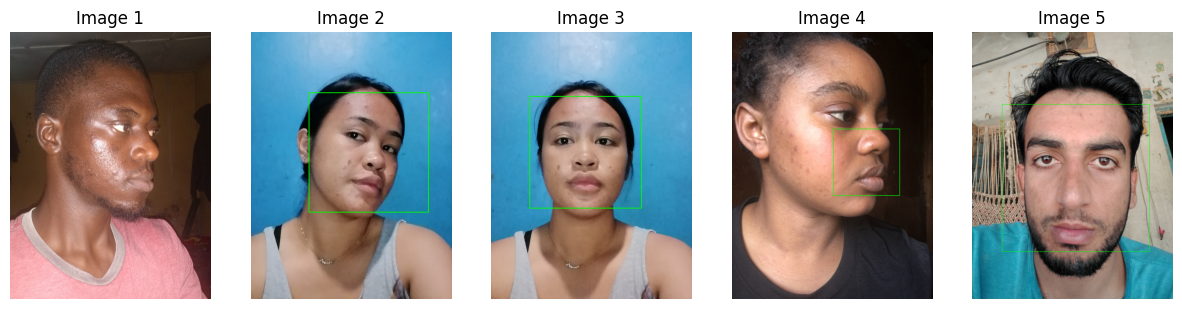

In [9]:
import cv2
import matplotlib.pyplot as plt
import random

# Load Haar cascade classifier
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
print(f"Loading Haar Cascade from: {face_cascade_path}")
face_cascade = cv2.CascadeClassifier(face_cascade_path)

def detect_face_and_draw_box(image_path):
    print(f"\n[INFO] Processing: {image_path}")
    
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"[ERROR] Failed to read image: {image_path}")
        return None
    
    print(f"[INFO] Original image shape: {img.shape}")
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print("[INFO] Converted to grayscale.")
    
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    print(f"[INFO] Faces detected: {len(faces)}")
    
    if len(faces) == 0:
        print(f"[WARNING] No face detected in {image_path}")
        return img  # Return original image without box
    
    # We expect exactly one face
    x, y, w, h = faces[0]
    print(f"[INFO] Face located at: x={x}, y={y}, w={w}, h={h}")
    
    # Draw rectangle around face (green box, thickness=3)
    boxed_img = img.copy()
    cv2.rectangle(boxed_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
    
    return boxed_img

# Select 5 random images from the list to check
random_images = random.sample(IMAGE_PATH_LIST, 5)

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(random_images, 1):
    boxed_img = detect_face_and_draw_box(img_path)
    if boxed_img is not None:
        plt.subplot(1, 5, i)
        plt.imshow(cv2.cvtColor(boxed_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i}")
        plt.axis('off')
plt.show()


## 3. Custom Dataset and Data Augmentation

We define a custom PyTorch dataset that loads the three views for each person, applies face detection, and performs data augmentation (random color jitter, etc.). The dataset is split into training and validation sets.

In [ ]:
# Cell 3: Define custom dataset with transformations

class DermatologyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.class_to_idx = {'acne': 0, 'bags': 1, 'redness': 2}
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = self.class_to_idx[row['type']]
        
        front = detect_face(IMAGE_PATH / row['front'])
        left = detect_face(IMAGE_PATH / row['left_side'])
        right = detect_face(IMAGE_PATH / row['right_side'])

        if self.transform:
            front = self.transform(front)
            left = self.transform(left)
            right = self.transform(right)

        images = torch.stack([front, left, right])  # shape: (3, C, H, W)
        return images, label

# Define data augmentation transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Split data into train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['type'], random_state=42)

# Create datasets
train_dataset = DermatologyDataset(train_df, transform=transform)
val_dataset = DermatologyDataset(val_df, transform=transforms.ToTensor())

# Test sample
sample_images, label = train_dataset[0]
print(f"Sample image tensor shape: {sample_images.shape}, Label: {label}")

## 4. Fine-tune Pretrained ResNet50

We load a pretrained ResNet50 model, modify the final layer for our classification task (acne, bags, redness, healthy), and set up the training loop. The model is trained on the augmented dataset.

In [ ]:
# Cell 4: Build and fine-tune ResNet50 model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Modify final layer for 3 classes + healthy (total 4)
model.fc = nn.Linear(model.fc.in_features, 4)  # acne, bags, redness, healthy
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Dummy training loop
def train_model(model, dataloader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in dataloader:
            inputs = inputs.view(-1, 3, 224, 224).to(device)  # Flatten (batch_size * 3 views)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {100.*correct/total:.2f}%")

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Train
train_model(model, train_loader, criterion, optimizer, epochs=5)

## 5. Predict Skin Condition for New Images

We define a function to predict the skin condition and output class probabilities for a new face image using the trained model.

In [ ]:
# Cell 5: Predict new image and show probabilities

from torch.nn.functional import softmax

def predict_image(model, image_path):
    model.eval()
    face = detect_face(image_path)
    face = transform(face).unsqueeze(0).to(device)  # Add batch dim
    with torch.no_grad():
        output = model(face)
        probs = softmax(output, dim=1).cpu().numpy()[0]
    classes = ['acne', 'bags', 'redness', 'healthy']
    pred_class = classes[np.argmax(probs)]
    return pred_class, dict(zip(classes, probs))

# Test prediction
test_path = IMAGE_PATH_LIST[0]  # Replace with any new image path
pred_class, probs = predict_image(model, test_path)
print(f"Predicted class: {pred_class}")
print(f"Class probabilities: {probs}")